  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=3529254ff36f4db674d52e4d50a861d028c0821156b7ac8378792002ab23296c
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 83.2 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
      Successfully uninstalled sympy-1.14.0
Simulating for p = 10
Epoch 1/5 | SamplePairs m=21130 | Mean Pair-Batch Loss: 12.5430 | Train MSE: 3.6211 | Test MSE: 3.8651 | Train C-index: 0.941 | Test C-index: 0.938
Epoch 2/5 | SamplePairs m=21130 | Mean Pair-Batch Loss: 5.0685 | Train MSE: 1.9521 | Test MSE: 

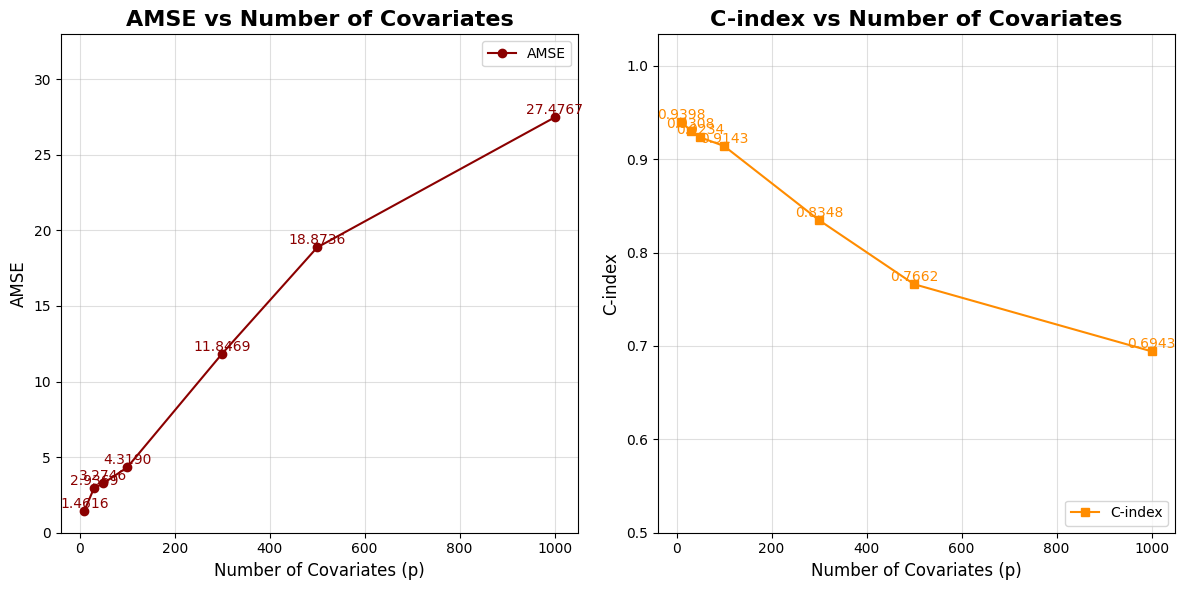

In [ ]:
!pip install lifelines
!pip install sympy==1.13.3

# === Import Required Libraries ===
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from lifelines import KaplanMeierFitter
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple


# === Model ===
class RNNAFTGRU(nn.Module):
    def __init__(self, cov_dim, hidden_dim=32, gru_layers=1, dropout=0.0):
        super().__init__()
        self.cov_dim = cov_dim
        self.input_dim = 1 + cov_dim
        self.hidden_dim = hidden_dim
        self.gru_layers = gru_layers

        self.gru = nn.GRU(
            input_size=self.input_dim,
            hidden_size=hidden_dim,
            num_layers=gru_layers,
            batch_first=True,
            dropout=dropout if gru_layers > 1 else 0.0
        )
        self.output = nn.Linear(hidden_dim, 1)
        self.init_fc = nn.Linear(cov_dim, gru_layers * hidden_dim)

    def initialize_hidden(self, X_static):
        h0_flat = torch.tanh(self.init_fc(X_static))
        h0 = h0_flat.view(self.gru_layers, X_static.size(0), self.hidden_dim)
        return h0

    def forward(self, X_in):
        covariates_seq = X_in[..., 1:]
        X_static = covariates_seq[:, 0, :]
        h0 = self.initialize_hidden(X_static)
        gru_out, h = self.gru(X_in, h0)
        yhat = self.output(gru_out).squeeze(-1)  # [batch, seq]
        return yhat, h

def batchify_subjects(subject_data: List[Dict], cov_dim: int):
    batch_size = len(subject_data)
    seq_lens = [len(s['log_gaps']) for s in subject_data]
    max_seq = max(seq_lens) if len(seq_lens) > 0 else 0
    prev_log_gaps = np.zeros((batch_size, max_seq, 1), dtype=np.float32)
    covariates = np.zeros((batch_size, max_seq, cov_dim), dtype=np.float32)
    log_gaps = np.zeros((batch_size, max_seq), dtype=np.float32)
    delta = np.zeros((batch_size, max_seq), dtype=np.float32)
    for i, s in enumerate(subject_data):
        l = seq_lens[i]
        if l == 0:
            continue
        if l > 1:
            prev_log_gaps[i, 1:l, 0] = s['log_gaps'][:-1]
        covariates[i, :l, :] = np.tile(s['covariates'], (l, 1))
        log_gaps[i, :l] = s['log_gaps']
        delta[i, :l] = s['delta']
    return (
        torch.tensor(prev_log_gaps, dtype=torch.float32),
        torch.tensor(covariates, dtype=torch.float32),
        torch.tensor(log_gaps, dtype=torch.float32),
        torch.tensor(delta, dtype=torch.float32),
        torch.tensor(seq_lens, dtype=torch.long)
    )

# === Gehan loss (full version left for reference) ===

class GehanLoss(nn.Module):
    """
    Original (full) Gehan loss that sums over all pairs. Kept for reference/testing.
    """
    def __init__(self, reduction='mean'):
        super().__init__()
        self.reduction = reduction

    def forward(self, pred_log_gaps, true_log_gaps, delta, seq_lens):
        device = pred_log_gaps.device
        batch, max_seq = pred_log_gaps.shape
        mask = (torch.arange(max_seq, device=device)[None, :] < seq_lens[:, None])
        events_mask = (delta == 1) & mask

        event_indices = events_mask.nonzero(as_tuple=False)
        if len(event_indices) == 0:
            return torch.tensor(0.0, requires_grad=True, device=device)

        e = true_log_gaps - pred_log_gaps  # residuals
        flat_e = e[mask]  # flatten only valid positions
        e_ij = e[event_indices[:, 0], event_indices[:, 1]]

        diffs = flat_e.unsqueeze(0) - e_ij.unsqueeze(1)  # [num_events, N_total]
        neg_part = torch.abs(torch.minimum(diffs, torch.zeros_like(diffs)))
        loss = neg_part.sum()
        if self.reduction == 'mean':
            loss = loss / event_indices.shape[0]
        return loss

# === Sub-sampling pairs utilities ===

def flatten_events(subjects: List[Dict]) -> Tuple[int, np.ndarray, np.ndarray, np.ndarray]:
    """
    Flatten events and provide mapping arrays.

    Returns:
      N_total: int (total number of event slots across subjects)
      subj_of_flat: np.array shape (N_total,) mapping flat_idx -> subject index i
      t_of_flat: np.array shape (N_total,) mapping flat_idx -> event time index j
      is_valid: np.array shape (N_total,) boolean - True if event exists (no padding)
    """
    seq_lens = [len(s['log_gaps']) for s in subjects]
    N_total = sum(seq_lens)
    subj_of_flat = np.empty(N_total, dtype=np.int32)
    t_of_flat = np.empty(N_total, dtype=np.int32)
    pos = 0
    for i, L in enumerate(seq_lens):
        for j in range(L):
            subj_of_flat[pos] = i
            t_of_flat[pos] = j
            pos += 1
    return N_total, subj_of_flat, t_of_flat

def sample_pairs_from_predictions(
    subjects: List[Dict],
    pred_log: np.ndarray,
    s: int,
    seed: int = None
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    For each uncensored residual (i,j) sample s indices from all other residuals
    (flat indexing). Returns arrays (I, J, L, K) each length m = n' * s, where
      (I[t], J[t]) is the left element (uncensored event),
      (L[t], K[t]) is the sampled counterpart.
    Sampling is uniform over other residuals excluding the same index.
    """
    rng = np.random.default_rng(seed)
    # Build flatten mapping and helpful arrays
    seq_lens = [len(su['log_gaps']) for su in subjects]
    prefix = np.concatenate([[0], np.cumsum(seq_lens)])
    N_total = int(prefix[-1])
    if N_total == 0:
        return (np.array([], dtype=int),) * 4

    # list of all flat indices
    all_flat = np.arange(N_total, dtype=int)

    # map from flat index to (i,j)
    subj_of_flat = np.empty(N_total, dtype=int)
    t_of_flat = np.empty(N_total, dtype=int)
    pos = 0
    for i, L in enumerate(seq_lens):
        for j in range(L):
            subj_of_flat[pos] = i
            t_of_flat[pos] = j
            pos += 1

    # gather uncensored flat indices
    uncensored_flats = []
    for i, ssub in enumerate(subjects):
        for j in range(len(ssub['log_gaps'])):
            if int(ssub['delta'][j]) == 1:
                flat_idx = prefix[i] + j
                uncensored_flats.append(flat_idx)
    uncensored_flats = np.array(uncensored_flats, dtype=int)
    n_prime = len(uncensored_flats)
    if n_prime == 0:
        return (np.array([], dtype=int),) * 4

    m = n_prime * s
    I = np.empty(m, dtype=int)
    J = np.empty(m, dtype=int)
    L = np.empty(m, dtype=int)
    K = np.empty(m, dtype=int)
    out_pos = 0
    for flat in uncensored_flats:
        # candidate pool excludes self
        pool = np.delete(all_flat, flat)
        replace = False if (pool.size >= s) else True
        chosen = rng.choice(pool, size=s, replace=replace)
        for ch in chosen:
            Ii = subj_of_flat[flat]
            Ji = t_of_flat[flat]
            Ll = subj_of_flat[ch]
            Kl = t_of_flat[ch]
            I[out_pos] = Ii
            J[out_pos] = Ji
            L[out_pos] = Ll
            K[out_pos] = Kl
            out_pos += 1
    return I, J, L, K

# === Metrics (unchanged from previous corrected implementation) ===

def pad_log_gaps(subjects, max_seq):
    n = len(subjects)
    arr = np.zeros((n, max_seq), dtype=np.float32)
    for i, s in enumerate(subjects):
        l = len(s['log_gaps'])
        arr[i, :l] = s['log_gaps']
    return arr

def compute_mse(subjects, pred_log):
    rows = []
    for i, subj in enumerate(subjects):
        for j in range(len(subj['log_gaps'])):
            rows.append({
                'i': i,
                'j': j,
                'log_gap': float(subj['log_gaps'][j]),
                'gap': float(np.exp(subj['log_gaps'][j])),
                'delta': int(subj['delta'][j]),
                'pred_log': float(pred_log[i, j])
            })
    df = pd.DataFrame(rows)
    if df.shape[0] == 0:
        return np.nan
    kmf = KaplanMeierFitter()
    try:
        kmf.fit(df['gap'], event_observed=1 - df['delta'])
        df['G_hat'] = kmf.predict(df['gap']).values
    except Exception:
        df['G_hat'] = 1.0
    df['G_hat'] = np.clip(df['G_hat'], 1e-6, 1.0)
    se = df['delta'] / df['G_hat'] * (df['log_gap'] - df['pred_log'])**2
    denom = df['delta'].sum()
    if denom == 0:
        return np.nan
    amse = se.sum() / denom
    return float(amse)

def ipcw_cindex(subjects, pred_log):
    rows = []
    for i, subj_i in enumerate(subjects):
        for j in range(len(subj_i['log_gaps'])):
            rows.append({
                'i': i,
                'j': j,
                'gap': float(np.exp(subj_i['log_gaps'][j])),
                'log_gap': float(subj_i['log_gaps'][j]),
                'delta': int(subj_i['delta'][j]),
                'pred_log': float(pred_log[i, j])
            })
    df = pd.DataFrame(rows)
    if df.shape[0] == 0:
        return np.nan
    kmf = KaplanMeierFitter()
    try:
        kmf.fit(df['gap'], event_observed=1 - df['delta'])
        df['G_hat'] = kmf.predict(df['gap']).values
    except Exception:
        df['G_hat'] = 1.0
    df['G_hat'] = np.clip(df['G_hat'], 1e-6, 1.0)
    num, denom = 0.0, 0.0
    for idx_i, row_i in df.iterrows():
        if row_i['delta'] != 1:
            continue
        for idx_k, row_k in df.iterrows():
            if row_i['i'] == row_k['i']:
                continue
            if row_i['gap'] < row_k['gap']:
                weight = 1.0 / row_i['G_hat'] if row_i['G_hat'] > 0 else 0.0
                concordant = 1.0 if row_i['pred_log'] < row_k['pred_log'] else 0.0
                num += weight * concordant
                denom += weight
    return float(num / denom) if denom > 0 else np.nan


# === Training with sub-sampled pairs ===

def train_rnn_aft_subsample_pairs(
    train_subjects,
    test_subjects,
    cov_dim=3,
    hidden_dim=32,
    epochs=10,
    pair_sample_s=2,
    pair_batch_b=64,
    lr=1e-3,
    device="cpu",
    seed=None
):
    device = torch.device(device)
    rng = np.random.default_rng(seed)
    model = RNNAFTGRU(cov_dim, hidden_dim=hidden_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    n_train = len(train_subjects)
    train_losses = []
    train_mse_hist = []
    test_mse_hist = []
    train_cidx_hist = []
    test_cidx_hist = []

    def predict_all_numpy(subjects):
        if len(subjects) == 0:
            return np.zeros((0, 0), dtype=np.float32)
        n = len(subjects)
        max_seq = max([len(s['log_gaps']) for s in subjects])
        X_prev_gaps, X_cov, Y_log_gaps, Y_delta, seq_lens = batchify_subjects(subjects, cov_dim)
        X_in = torch.cat([X_prev_gaps, X_cov], dim=-1).to(device)
        with torch.no_grad():
            yhat, _ = model(X_in)
        pred_log = yhat.cpu().numpy()
        out = np.zeros_like(pred_log)
        for i in range(n):
            out[i, :seq_lens[i]] = pred_log[i, :seq_lens[i]]
        return out

    for epoch in range(epochs):
        model.train()
        # Step 1: snapshot predictions to sample pairs (use numpy snapshot)
        pred_log_train_snapshot = predict_all_numpy(train_subjects)

        # Step 2: sample pairs (m = n' * s)
        I, J, L, K = sample_pairs_from_predictions(train_subjects, pred_log_train_snapshot, pair_sample_s, seed=rng.integers(1_000_000))
        m = I.size
        # If nothing was sampled (no uncensored events), fall back to no-op update pass
        if m == 0:
            print(f"Epoch {epoch+1}: no uncensored events found, skipping pair-subsampling updates.")
            train_losses.append(0.0)
            train_mse_hist.append(compute_mse(train_subjects, pred_log_train_snapshot))
            test_mse_hist.append(compute_mse(test_subjects, predict_all_numpy(test_subjects)))
            train_cidx_hist.append(ipcw_cindex(train_subjects, pred_log_train_snapshot))
            test_cidx_hist.append(ipcw_cindex(test_subjects, predict_all_numpy(test_subjects)))
            continue

        # shuffle sampled pairs
        perm_pairs = rng.permutation(m)
        I, J, L, K = I[perm_pairs], J[perm_pairs], L[perm_pairs], K[perm_pairs]

        # Precompute some constants for weighting
        N_total = sum(len(s['log_gaps']) for s in train_subjects)
        # number of uncensored events n'
        n_prime = int(np.sum([np.sum(s['delta']) for s in train_subjects]))

        # per-epoch optimization over sampled pairs mini-batches
        losses_epoch = []
        # iterate mini-batches of pairs
        for start in range(0, m, pair_batch_b):
            end = min(start + pair_batch_b, m)
            batch_slice = slice(start, end)
            Ib, Jb, Lb, Kb = I[batch_slice], J[batch_slice], L[batch_slice], K[batch_slice]

            # find unique subject indices in this pairs-batch
            unique_subjects, inv_idx = np.unique(np.concatenate([Ib, Lb]), return_inverse=True)
            # map global subject idx -> local index
            g2l = {int(g): int(l) for l, g in enumerate(unique_subjects)}
            # build small sub-batch of subjects
            sub_subjects = [train_subjects[int(g)] for g in unique_subjects]
            X_prev_gaps, X_cov, Y_log_gaps, Y_delta, seq_lens = batchify_subjects(sub_subjects, cov_dim)
            X_in = torch.cat([X_prev_gaps, X_cov], dim=-1).to(device)
            Y_log_gaps = Y_log_gaps.to(device)
            Y_delta = Y_delta.to(device)
            seq_lens_t = seq_lens.to(device)

            optimizer.zero_grad()
            yhat_sub, _ = model(X_in)  # [n_sub, max_sub_seq]
            # For each pair we need predicted log for left and right
            # Build tensors of predictions corresponding to pairs
            left_preds = []
            right_preds = []
            left_trues = []
            right_trues = []
            for idx_pair in range(Ib.size):
                gi = int(Ib[idx_pair]); gj = int(Jb[idx_pair])
                gl = int(Lb[idx_pair]); gk = int(Kb[idx_pair])
                li = g2l[gi]; ll = g2l[gl]
                # grab as torch scalars
                # Note: ensure event index within seq_lens for sub-batch (should be by construction)
                pred_ij = yhat_sub[li, gj]
                pred_lk = yhat_sub[ll, gk]
                left_preds.append(pred_ij)
                right_preds.append(pred_lk)
                left_trues.append(torch.tensor(float(train_subjects[gi]['log_gaps'][gj]), device=device))
                right_trues.append(torch.tensor(float(train_subjects[gl]['log_gaps'][gk]), device=device))
            left_preds = torch.stack(left_preds)  # [batch_pairs_in_minibatch]
            right_preds = torch.stack(right_preds)
            left_trues = torch.stack(left_trues)
            right_trues = torch.stack(right_trues)

            # residuals e = true - pred
            e_ij = left_trues - left_preds
            e_lk = right_trues - right_preds
            diffs = e_lk - e_ij
            neg_part = torch.abs(torch.minimum(diffs, torch.zeros_like(diffs)))
            sum_neg = neg_part.sum()

            # scaling for unbiased estimator:
            # For each uncensored event we sampled s from N_total - 1 possibilities. So factor = (N_total - 1) / s
            # Our overall GehanLoss with reduction='mean' divides by n' (#uncensored events).
            scale = float((N_total - 1) / max(1, pair_sample_s))
            loss_batch = sum_neg * scale
            if n_prime > 0:
                loss_batch = loss_batch / float(n_prime)
            # backpropagate
            loss_batch.backward()
            optimizer.step()
            losses_epoch.append(float(loss_batch.detach().cpu().numpy()))

        mean_epoch_loss = float(np.mean(losses_epoch)) if len(losses_epoch) > 0 else 0.0
        train_losses.append(mean_epoch_loss)

        # Evaluate on train and test sets (use current model to predict)
        model.eval()
        pred_log_train = predict_all_numpy(train_subjects)
        pred_log_test = predict_all_numpy(test_subjects)
        mse_train = compute_mse(train_subjects, pred_log_train)
        mse_test = compute_mse(test_subjects, predict_all_numpy(test_subjects))
        train_mse_hist.append(mse_train)
        test_mse_hist.append(mse_test)
        cidx_train = ipcw_cindex(train_subjects, pred_log_train)
        cidx_test = ipcw_cindex(test_subjects, predict_all_numpy(test_subjects))
        train_cidx_hist.append(cidx_train)
        test_cidx_hist.append(cidx_test)

        print(f"Epoch {epoch + 1}/{epochs} | SamplePairs m={m} | Mean Pair-Batch Loss: {mean_epoch_loss:.4f} | Train MSE: {mse_train:.4f} | Test MSE: {mse_test:.4f} | Train C-index: {np.nan_to_num(cidx_train):.3f} | Test C-index: {np.nan_to_num(cidx_test):.3f}")

    # final evaluation
    model.eval()
    pred_log_train = predict_all_numpy(train_subjects)
    pred_log_test = predict_all_numpy(test_subjects)
    mse_train = compute_mse(train_subjects, pred_log_train)
    mse_test = compute_mse(test_subjects, pred_log_test)
    cidx_train = ipcw_cindex(train_subjects, pred_log_train)
    cidx_test = ipcw_cindex(test_subjects, pred_log_test)

    return {
        "model": model,
        "mse_train": mse_train,
        "mse_test": mse_test,
        "cindex_train": cidx_train,
        "cindex_test": cidx_test,
        "pred_log_train": pred_log_train,
        "pred_log_test": pred_log_test,
        "train_losses": train_losses,
        "train_mse_hist": train_mse_hist,
        "test_mse_hist": test_mse_hist,
        "train_cidx_hist": train_cidx_hist,
        "test_cidx_hist": test_cidx_hist,
    }


# === Data Generation Utilities ===
def generate_highdim_covariates(n, p):
    """
    Generate high-dimensional covariates where the first three features are signals.
    Remaining features are random noise with moderate correlation.
    """
    x1 = np.random.binomial(1, 0.5, size=n).astype(np.float32)
    X = np.zeros((n, p), dtype=np.float32)
    X[:, 0] = x1
    for j in range(1, p):
        X[:, j] = np.random.normal(loc=X[:, j - 1] / 3, scale=1, size=n).astype(np.float32)
    return X

def generate_gap_times(n, signal_func, p, error_dist, sigma_b=0.5, lambda_poisson=2, seed=None):
    """
    Generate subject gap times based on given parameters, noise, and covariates.
    """
    np.random.seed(seed)
    X = generate_highdim_covariates(n, p)
    means = signal_func(X)
    K = np.random.poisson(lambda_poisson, size=n)
    subjects = []
    for i in range(n):
        ki = K[i] if K[i] > 0 else 1
        xi = X[i]
        mui = means[i]
        bi = np.random.normal(0, sigma_b)
        eta = np.random.normal(0, 1, size=ki)  # Gaussian error
        eps = bi + eta
        log_gaps = mui + eps
        gaps = np.exp(log_gaps)
        subjects.append({
            "covariates": xi,
            "log_gaps": log_gaps,
            "gaps": gaps,
        })
    return subjects

def apply_censoring(subject_list, censoring_prop=0.25, seed=None):
    """
    Censor the data based on a fixed proportion.
    """
    np.random.seed(seed)
    for subj in subject_list:
        event_times = subj["gaps"]
        total_time = np.sum(event_times)
        max_time = total_time * censoring_prop
        censored_gaps = np.zeros_like(event_times)
        delta = np.zeros_like(event_times, dtype=np.int32)

        running_sum = 0
        for i, gap in enumerate(event_times):
            if running_sum + gap <= max_time:
                censored_gaps[i] = gap
                delta[i] = 1
                running_sum += gap
            else:
                censored_gaps[i] = max(0, max_time - running_sum)
                delta[i] = 0
                break
        subj["censored_gaps"] = censored_gaps
        subj["delta"] = delta
    return subject_list

def compute_censoring_proportion(subjects):
    """
    subjects: list of dicts with key 'delta' (1 = observed event, 0 = censored)
    Returns: (prop_observed, prop_censored, total_events, observed_count, censored_count)
    """
    total = 0
    observed = 0
    for s in subjects:
        if 'delta' in s:
            total += len(s['delta'])
            observed += int(np.sum(s['delta']))
    censored = total - observed
    prop_observed = observed / total if total > 0 else float('nan')
    prop_censored = censored / total if total > 0 else float('nan')
    return prop_observed, prop_censored, total, observed, censored

def prepare_subjects_for_nn(subject_list):
    """
    Reorganize data to make it suitable for NN input.
    """
    return [
        {
            "covariates": subj["covariates"],
            "log_gaps": subj["log_gaps"],
            "delta": subj["delta"]
        }
        for subj in subject_list
    ]


# === High-dimensional Analysis Simulation ===
def run_highdim_simulation(p_values, n_train=1000, n_test=2000, epochs=5, device="cpu"):
    def f_signal(X):
        x1, x2, x3 = X[:, 0], X[:, 1], X[:, 2]
        # True mean signal function
        return x1 - 6 * x2 + 4 * x3

    results_amse = []
    results_cindex = []

    for p in p_values:
        print(f"Simulating for p = {p}")

        # Generate training and test datasets for the current number of covariates
        train_subjects = generate_gap_times(
            n_train, signal_func=f_signal, p=p, error_dist="normal", sigma_b=0.5, seed=42
        )
        train_subjects = apply_censoring(train_subjects, censoring_prop=3000, seed=42)
        train_subjects = prepare_subjects_for_nn(train_subjects)

        test_subjects = generate_gap_times(
            n_test, signal_func=f_signal, p=p, error_dist="normal", sigma_b=0.5, seed=42
        )
        test_subjects = apply_censoring(test_subjects, censoring_prop=3000, seed=42)
        test_subjects = prepare_subjects_for_nn(test_subjects)

        # Train the RNN-AFT model
        results = train_rnn_aft_subsample_pairs(
            train_subjects, test_subjects,
            cov_dim=p, hidden_dim=32, epochs=epochs,
            pair_sample_s=10, pair_batch_b=64, lr=1e-3, device=device
        )

        # Collect final AMSE and C-index for this p value
        amse = results["mse_test"]
        cindex = results["cindex_test"]

        results_amse.append(amse)
        results_cindex.append(cindex)
        print(f"p = {p} | AMSE = {amse:.4f} | C-index = {cindex:.4f}")

    return p_values, results_amse, results_cindex

# === Enhanced Plotting Utilities with Annotations ===
def plot_results(p_values, amse, cindex, output_dir="."):
    plt.figure(figsize=(12, 6))

    # Plot AMSE
    plt.subplot(1, 2, 1)
    plt.plot(p_values, amse, marker='o', color='darkred', label='AMSE')
    plt.title('AMSE vs Number of Covariates', fontsize=16, fontweight='bold')
    plt.xlabel('Number of Covariates (p)', fontsize=12)
    plt.ylabel('AMSE', fontsize=12)
    plt.ylim(0, max(amse) * 1.2)  # Start y-axis at 0, extend it slightly above the max value
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(alpha=0.4)

    # Annotate AMSE values
    for i, val in enumerate(amse):
        plt.text(p_values[i], val, f"{val:.4f}", fontsize=10, ha='center', va='bottom', color="darkred")

    plt.legend(loc='upper right')

    # Plot C-index
    plt.subplot(1, 2, 2)
    plt.plot(p_values, cindex, marker='s', color='darkorange', label='C-index')
    plt.title('C-index vs Number of Covariates', fontsize=16, fontweight='bold')
    plt.xlabel('Number of Covariates (p)', fontsize=12)
    plt.ylabel('C-index', fontsize=12)
    plt.ylim(0.5, max(cindex) * 1.1)  # Start y-axis at 0.5, extend it slightly above the max value
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(alpha=0.4)

    # Annotate C-index values
    for i, val in enumerate(cindex):
        plt.text(p_values[i], val, f"{val:.4f}", fontsize=10, ha='center', va='bottom', color="darkorange")

    plt.legend(loc='lower right')

    plt.tight_layout()
    plt.show()



# === Main Entry Point ===
if __name__ == "__main__":
    p_values = [10, 30, 50, 100, 300, 500, 1000]
    p_vals, amse_vals, cindex_vals = run_highdim_simulation(p_values, epochs=5, device="cpu")
    plot_results(p_vals, amse_vals, cindex_vals, output_dir="results")

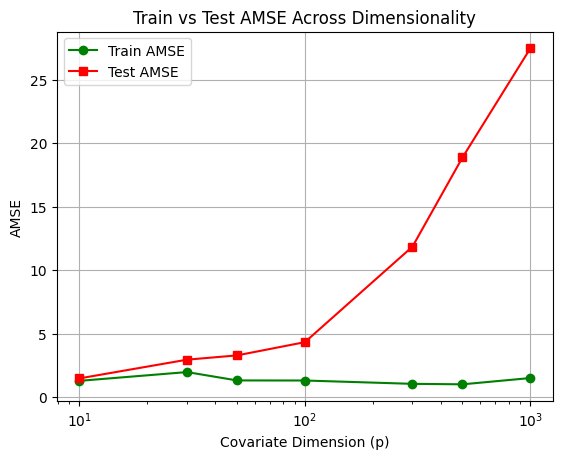

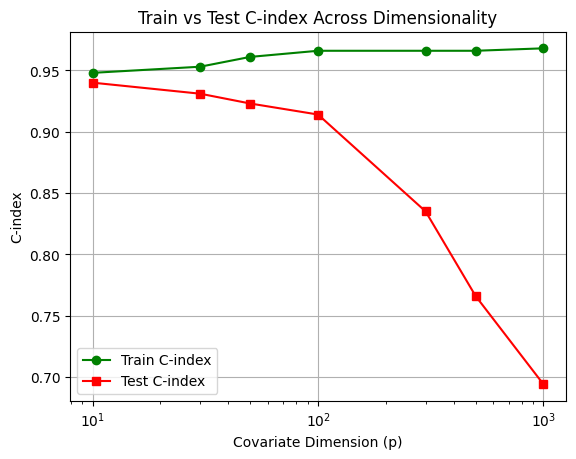

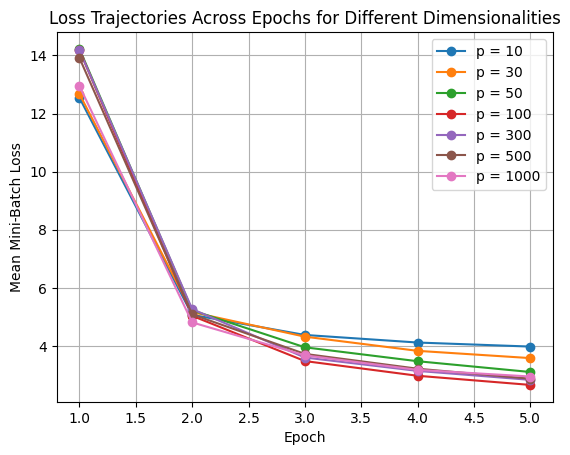

In [12]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np

# Data
p = np.array([10, 30, 50, 100, 300, 500, 1000])

train_amse = np.array([
    1.2689,  # p = 10
    1.9598,  # p = 30
    1.3012,  # p = 50
    1.2953,  # p = 100
    1.0328,  # p = 300
    0.9947,  # p = 500
    1.4898   # p = 1000
])

test_amse = np.array([
    1.4616,  # p = 10
    2.9369,  # p = 30
    3.2746,  # p = 50
    4.3190,  # p = 100
    11.8469, # p = 300
    18.8736, # p = 500
    27.4767  # p = 1000
])

# Plot
plt.figure()
plt.plot(p, train_amse, marker='o', color='green', label='Train AMSE')
plt.plot(p, test_amse, marker='s', color='red', label='Test AMSE')

plt.xscale('log')
plt.xlabel("Covariate Dimension (p)")
plt.ylabel("AMSE")
plt.title("Train vs Test AMSE Across Dimensionality")
plt.legend()
plt.grid(True)

plt.show()

# Data
p = np.array([10, 30, 50, 100, 300, 500, 1000])
train_cindex = np.array([0.948, 0.953, 0.961, 0.966, 0.966, 0.966, 0.968])
test_cindex  = np.array([0.940, 0.931, 0.923, 0.914, 0.835, 0.766, 0.694])

# Plot
plt.figure()
plt.plot(p, train_cindex, marker='o', color='green', label='Train C-index')
plt.plot(p, test_cindex, marker='s', color='red', label='Test C-index')

plt.xscale('log')
plt.xlabel("Covariate Dimension (p)")
plt.ylabel("C-index")
plt.title("Train vs Test C-index Across Dimensionality")
plt.legend()
plt.grid(True)

plt.show()


import matplotlib.pyplot as plt
import numpy as np

# Epochs
epochs = np.arange(1, 6)

# Mean pair-batch loss across epochs for each p
loss_dict = {
    10:   [12.5430, 5.0685, 4.3774, 4.1163, 3.9772],
    30:   [12.6730, 5.1627, 4.3184, 3.8303, 3.5802],
    50:   [14.2263, 5.2264, 3.9518, 3.4729, 3.1016],
    100:  [14.1889, 5.0352, 3.4781, 2.9716, 2.6568],
    300:  [14.1785, 5.2661, 3.6005, 3.1398, 2.8307],
    500:  [13.9172, 5.0843, 3.7247, 3.2148, 2.8712],
    1000: [12.9502, 4.8092, 3.6750, 3.1749, 2.9462],
}

# Plot
plt.figure()

for p, losses in loss_dict.items():
    plt.plot(epochs, losses, marker='o', label=f"p = {p}")

plt.xlabel("Epoch")
plt.ylabel("Mean Mini-Batch Loss")
plt.title("Loss Trajectories Across Epochs for Different Dimensionalities")
plt.legend()
plt.grid(True)

plt.show()

